#  Решение задачи регрессии при помощи пакета `torch`. Метрики.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann 
* https://pytorch.org/docs/stable/nn.html
* https://pytorch.org/docs/stable/optim.html
* https://github.com/Lightning-AI/torchmetrics
* https://pytorch.org/docs/stable/generated/torch.no_grad.html
* https://pytorch-lightning.readthedocs.io/en/2.1.2/pytorch/ecosystem/metrics.html#torchmetrics

## Задачи для совместного разбора

In [23]:
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked
import torch as th

Scalar = TensorType[()]
patch_typeguard()

1\. Используя реализацию из `torch.nn`, решите задачу регрессии. Для расчета градиентов воспользуйтесь возможностями по автоматическому дифференцированию `torch`. В качестве функции потерь используйте собственную реализацию MSE. Для настройки весов реализуйте пакетный градиентный спуск с использованием `torch.optim.SGD`.

In [24]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y)

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию полносвязного слоя из `torch.nn` решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Для создания модели опишите класс `SineModel`.

Предлагаемая архитектура нейронной сети: 
1. Полносвязный слой с 100 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).

Выведите график изменения значения функции потерь в процессе обучения. Логику расчета значения функции потерь на уровне эпохи реализуйте самостоятельно.

- [ ] Проверено на семинаре

In [25]:
import torch 

X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size()) 

In [26]:
import torch.nn as nn
class SineModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.linear1 = nn.Linear(n_features, n_hidden)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(n_hidden, n_out)

    def forward(self, X: TensorType["batch", "n_features"]) -> TensorType["batch", 1]:
        out = self.linear1(X)
        out = self.relu(out)
        out = self.linear2(out)
        return out

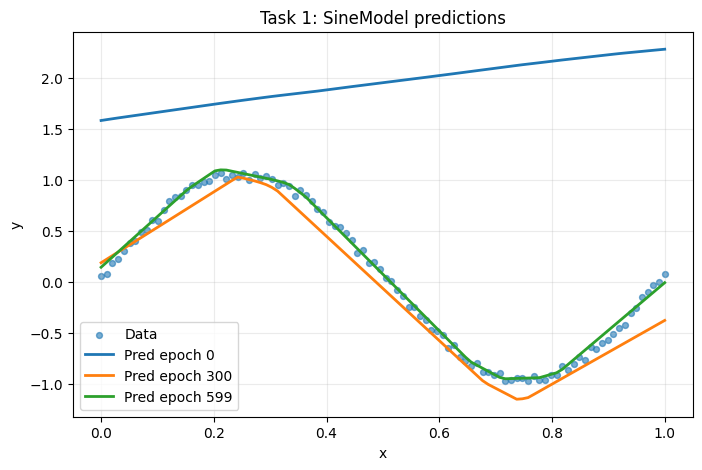

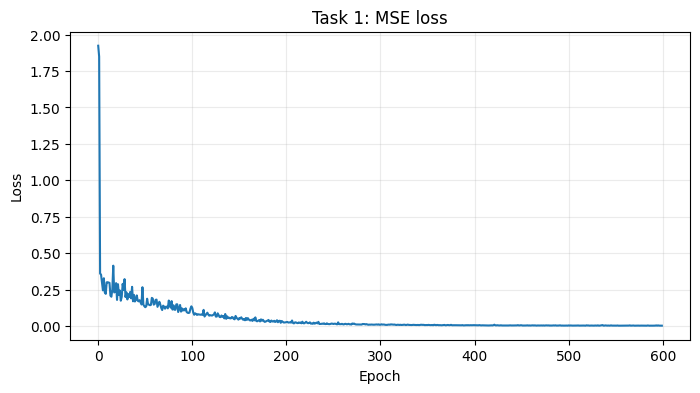

In [27]:
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

torch.manual_seed(42)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = SineModel(n_features=1, n_hidden=100, n_out=1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

epochs = 600
epoch_losses = []
snapshots = {}
checkpoints = {0, epochs // 2, epochs - 1}

for epoch in range(epochs):
    model.train()
    epoch_loss_sum = 0.0
    n_batches = 0

    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_loss_sum += loss.item()
        n_batches += 1

    epoch_losses.append(epoch_loss_sum / n_batches)

    if epoch in checkpoints:
        model.eval()
        with torch.no_grad():
            snapshots[epoch] = model(X).detach().clone()

# График 1: точки + промежуточные предсказания
order = torch.argsort(X[:, 0])
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0].numpy(), y[:, 0].numpy(), s=18, alpha=0.6, label='Data')
for ep in sorted(snapshots.keys()):
    yp = snapshots[ep][order, 0].numpy()
    plt.plot(X[order, 0].numpy(), yp, linewidth=2, label=f'Pred epoch {ep}')
plt.title('Task 1: SineModel predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# График 2: loss по эпохам
plt.figure(figsize=(8, 4))
plt.plot(epoch_losses)
plt.title('Task 1: MSE loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.25)
plt.show()

<p class="task" id="2"></p>

2\. Повторите решение задачи 1, изменив модель. Для создания модели создайте объект класса `nn.Sequential`.

Предлагаемая архитектура нейронной сети: 
1. Полносвязный слой с 50 нейронами
2. Активация Tanh
3. Полносвязный слой с 1 нейроном

- [ ] Проверено на семинаре

In [28]:
import torch 

X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size()) 

In [29]:
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

torch.manual_seed(42)
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

model_seq = nn.Sequential(
    nn.Linear(1, 50),
    nn.Tanh(),
    nn.Linear(50, 1),
)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model_seq.parameters(), lr=0.05)

epochs = 600
for epoch in range(epochs):
    model_seq.train()
    epoch_loss_sum = 0.0
    n_batches = 0

    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model_seq(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        epoch_loss_sum += loss.item()
        n_batches += 1

    if epoch % 200 == 0:
        print(f"epoch={epoch}, loss={epoch_loss_sum / n_batches:.6f}")

epoch=0, loss=0.627630
epoch=200, loss=0.223009
epoch=400, loss=0.132429


<p class="task" id="3"></p>

3\. Используя реализацию полносвязного слоя из `torch.nn`, решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Перенесите вычисления на GPU и сравните время обучения с и без использования GPU. Решение должно корректно работать в случае отсутствия GPU без дополнительных изменений в коде. 

- [ ] Проверено на семинаре

In [30]:
from sklearn.datasets import make_regression
import torch as th

X, y, coef = make_regression(
    n_samples=10000, 
    n_features=10, 
    n_informative=6, 
    coef=True, 
    bias=0.5, 
    random_state=42
)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [31]:
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import time

def train_linear_on_device(X_src, y_src, device, epochs=200, batch_size=128, lr=0.01):
    X_dev = X_src.to(device)
    y_dev = y_src.to(device)

    dataset = TensorDataset(X_dev, y_dev)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = nn.Linear(10, 1).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    if device.type == 'cuda':
        torch.cuda.synchronize()
    start = time.perf_counter()

    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return elapsed

cpu_time = train_linear_on_device(X, y, torch.device('cpu'))
print(f"CPU training time: {cpu_time:.4f} sec")

if torch.cuda.is_available():
    gpu_time = train_linear_on_device(X, y, torch.device('cuda'))
    print(f"GPU training time: {gpu_time:.4f} sec")
else:
    print("CUDA is not available; GPU benchmark skipped.")

CPU training time: 15.5019 sec
CUDA is not available; GPU benchmark skipped.


<p class="task" id="4"></p>

4\. Повторите решение задач 1-2, используя для расчета значения функции потерь за эпоху метрику `MeanMetric` из пакета `torchmetrics`. Добавьте в цикл обучения расчет метрики $R^2$ (воспользуйтесь реализацией из `torchmetrics`). Выведите на экран график изменения значения функции потерь и метрики $R^2$ по эпохам в процессе обучения.

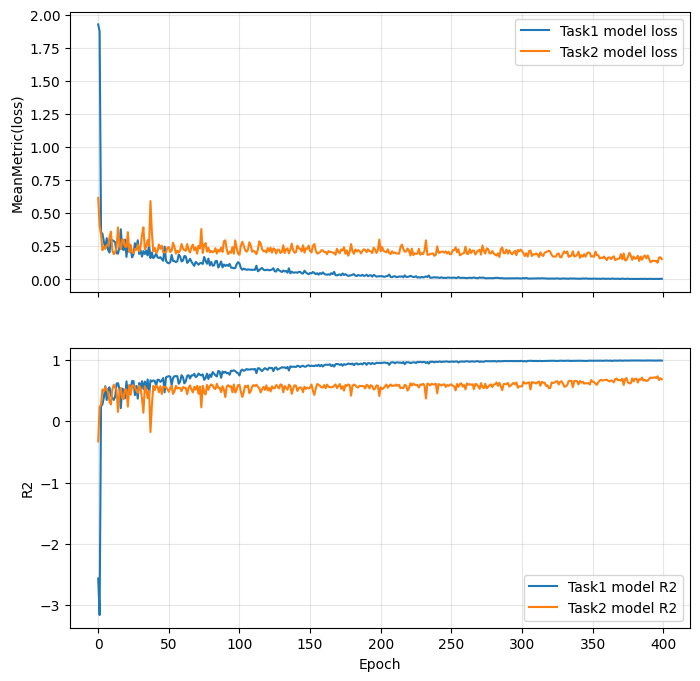

In [32]:
from torchmetrics import MeanMetric, R2Score
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

def train_with_metrics(model, X_data, y_data, epochs=400, batch_size=16, lr=0.05):
    dataset = TensorDataset(X_data, y_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    loss_history = []
    r2_history = []

    for _ in range(epochs):
        model.train()
        loss_metric = MeanMetric()
        r2_metric = R2Score()

        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            loss_metric.update(loss.detach().cpu())
            r2_metric.update(pred.detach().cpu(), yb.detach().cpu())

        loss_history.append(loss_metric.compute().item())
        r2_history.append(r2_metric.compute().item())

    return loss_history, r2_history

# Данные задач 1-2
X_m = torch.linspace(0, 1, 100).view(-1, 1)
y_m = torch.sin(2 * torch.pi * X_m) + 0.1 * torch.rand(X_m.size())

torch.manual_seed(42)
model1 = SineModel(n_features=1, n_hidden=100, n_out=1)
loss1, r21 = train_with_metrics(model1, X_m, y_m)

torch.manual_seed(42)
model2 = nn.Sequential(
    nn.Linear(1, 50),
    nn.Tanh(),
    nn.Linear(50, 1),
)
loss2, r22 = train_with_metrics(model2, X_m, y_m)

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes[0].plot(loss1, label='Task1 model loss')
axes[0].plot(loss2, label='Task2 model loss')
axes[0].set_ylabel('MeanMetric(loss)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(r21, label='Task1 model R2')
axes[1].plot(r22, label='Task2 model R2')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('R2')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show()

<p class="task" id="5"></p>

5\. Повторите решение задач 1-2, изменив функцию потерь. Обучите модель, используя три функции потерь: `MSELoss`, `L1Loss` и `HuberLoss` - и выведите на одном графике динамику изменения метрики $R^2$ по эпохам для каждой модели в процессе обучения. Добавьте подписи полученных кривых.

- [ ] Проверено на семинаре

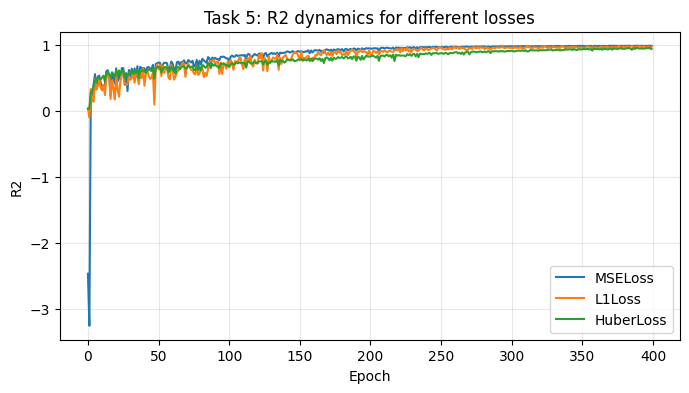

In [33]:
from torchmetrics import R2Score
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

def train_r2_with_loss(loss_fn, X_data, y_data, epochs=400, batch_size=16, lr=0.05):
    torch.manual_seed(42)
    model = SineModel(n_features=1, n_hidden=100, n_out=1)
    dataset = TensorDataset(X_data, y_data)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    r2_history = []
    for _ in range(epochs):
        model.train()
        r2_metric = R2Score()

        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            r2_metric.update(pred.detach().cpu(), yb.detach().cpu())

        r2_history.append(r2_metric.compute().item())

    return r2_history

X_loss = torch.linspace(0, 1, 100).view(-1, 1)
y_loss = torch.sin(2 * torch.pi * X_loss) + 0.1 * torch.rand(X_loss.size())

r2_mse = train_r2_with_loss(nn.MSELoss(), X_loss, y_loss)
r2_l1 = train_r2_with_loss(nn.L1Loss(), X_loss, y_loss)
r2_huber = train_r2_with_loss(nn.HuberLoss(), X_loss, y_loss)

plt.figure(figsize=(8, 4))
plt.plot(r2_mse, label='MSELoss')
plt.plot(r2_l1, label='L1Loss')
plt.plot(r2_huber, label='HuberLoss')
plt.xlabel('Epoch')
plt.ylabel('R2')
plt.title('Task 5: R2 dynamics for different losses')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<p class="task" id="6"></p>

6\. Повторите решение задач 1-2, разделив датасет на обучающую и тестовую выборку в соотношении 80% на 20%. Обучите модель. Для тестовой выборки посчитайте и выведите на экран значения метрик:

- MAE;
- MAPE;
- MSE;
- MSLE (MeanSquaredLogError).
 

- [ ] Проверено на семинаре

In [34]:
from sklearn.model_selection import train_test_split
from torchmetrics.regression import MeanAbsoluteError, MeanAbsolutePercentageError, MeanSquaredError, MeanSquaredLogError
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Данные задач 1-2
X_eval = torch.linspace(0, 1, 100).view(-1, 1)
y_eval = torch.sin(2 * torch.pi * X_eval) + 0.1 * torch.rand(X_eval.size())

X_train, X_test, y_train, y_test = train_test_split(
    X_eval.numpy(),
    y_eval.numpy(),
    test_size=0.2,
    random_state=42,
    shuffle=True,
 )
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

torch.manual_seed(42)
model = SineModel(n_features=1, n_hidden=100, n_out=1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

epochs = 600
for _ in range(epochs):
    model.train()
    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    y_pred_test = model(X_test)

mae = MeanAbsoluteError()(y_pred_test, y_test).item()
mape = MeanAbsolutePercentageError()(y_pred_test, y_test).item()
mse = MeanSquaredError()(y_pred_test, y_test).item()

offset = max(0.0, -min(y_pred_test.min().item(), y_test.min().item()) + 1e-6)
msle = MeanSquaredLogError()(y_pred_test + offset, y_test + offset).item()

print(f"MAE:  {mae:.6f}")
print(f"MAPE: {mape:.6f}")
print(f"MSE:  {mse:.6f}")
print(f"MSLE: {msle:.6f}")

MAE:  0.051032
MAPE: 1.410022
MSE:  0.004568
MSLE: 0.001330
